# XGBoost

In [1]:
from dotenv import load_dotenv
from mlModels.regression.data.data import getData, getRegressionData
from database.db import getConnection
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor as xgbr
from utils.enums import Mappings, Listings, Features
from sklearn.cluster import KMeans
from mlModels.kmeans.locationClustering import findBestFittingK, projectCoords
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.chdir("/home/florian/Desktop/immopreis-regression")

load_dotenv("database/.env")
conn = getConnection()

df = getData(filter_type=Listings.FINANCE_TYPE, filter_val="buy")
conn.close()


# Location ppm2 mean

w_postcode = n_postcode / (n_postcode + k1)

w_cluster_raw = n_cluster / (n_cluster + k2)

w_cluster = (1 - w_postcode) * w_cluster_raw

w_global = (1 - w_postcode) * (1 - w_cluster_raw)

In [2]:
postcode_trust = 15
cluster_trust = 15
global_ppm2_mean = df[Features.PPM2].mean()

# Postcodes
postcode_stats = df.groupby(Listings.POSTCODE)[Features.PPM2].agg(["mean", "count"])
postcode_stats.columns = ["postcode_mean", "postcode_count"]
df = df.merge(postcode_stats, on=Listings.POSTCODE, how="left")



### K-Mean Cluster Mean

calculated k's: 13, 97, 99

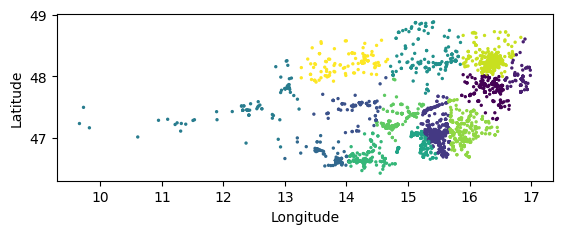

In [3]:
df_cluster_mean = pd.DataFrame()

df_cluster_data = df[[Listings.ID, Listings.LAT, Listings.LON, Features.PPM2]].copy()
df_cluster_data.drop(
    df_cluster_data[lambda d: (d[Listings.LAT] < 40) | (d[Listings.LON] < 5)].index,
    inplace=True
)

coords = df_cluster_data[[Listings.LON, Listings.LAT]].values


kmeans = KMeans(n_clusters=13, random_state=42)
labels = kmeans.fit_predict(coords)
df_cluster_data["cluster"] = labels
means = df_cluster_data.groupby("cluster")[Features.PPM2].mean()
df_cluster_data["cluster_mean"] = df_cluster_data["cluster"].map(means)
df_cluster_mean = df_cluster_data[[Listings.ID, "cluster", "cluster_mean"]].copy()

plt.figure()
plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(coords[:, 0], coords[:, 1], c=labels, s=2)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

df = df.merge(df_cluster_mean, on=Listings.ID, how="left")
cluster_counts = df.groupby("cluster")[Features.PPM2].count().rename("cluster_count")
df = df.merge(cluster_counts, on="cluster", how="left")



### Calc cluster means

In [4]:
df["w_postcode"] = df["postcode_count"] / (df["postcode_count"] + postcode_trust)
df["w_cluster_raw"] = df["cluster_count"] / (df["cluster_count"] + cluster_trust)
df["w_cluster"] = (1 - df["w_postcode"]) * df["w_cluster_raw"]
df["w_global"] = (1 - df["w_postcode"]) * (1 - df["w_cluster_raw"])
df["location_cluster_mean_ppm2"] = (
    df["w_postcode"] * df["postcode_mean"]
    + df["w_cluster"] * df["cluster_mean"]
    + df["w_global"] * global_ppm2_mean
)

print(df["location_cluster_mean_ppm2"].describe())

count    10310.000000
mean         6.328980
std          0.797662
min          3.413370
25%          5.920906
50%          6.639379
75%          6.790935
max          8.088265
Name: location_cluster_mean_ppm2, dtype: float64


### Location Cleanup

In [5]:
df.drop(columns=["w_postcode", "postcode_count", "w_cluster_raw", "cluster_count",
                 "w_cluster", "cluster", "cluster_mean", "w_global", "postcode_mean"], inplace=True)

# Prepare df

In [6]:
df = df.dropna(subset=["rooms"])
df = df.drop(columns=[Listings.ID, Listings.HWB, Listings.HWB_CLASS, Listings.FGEE, Listings.FGEE_CLASS, Listings.POSTCODE])
df.drop(columns=[c for c in df.columns if c.startswith("state_")], inplace=True)
df.drop_duplicates(subset=[Listings.LAT, Listings.LON, Features.PPM2], inplace=True)

# Drop POI counter -> leakage
#df.drop(columns=[c for c in df.columns if c.startswith("log_count_poi_")], inplace=True)
print("Num duplicated: " + str(df.duplicated(subset=[Listings.LAT, Listings.LON, Features.PPM2]).sum()))

# split into house and apt data
# houses
df_house = df[df[Listings.PROPERTY_TYPE].isin(Mappings.HOUSE_COLS)].copy()
df_y_house = df_house[Features.PPM2]
df_house.drop(columns=[Listings.PROPERTY_TYPE, Features.PPM2], inplace=True)
df_X_house = df_house

# apt
df_apt = df[df[Listings.PROPERTY_TYPE].isin(Mappings.APARTMENT_COLS)].copy()
df_y_apt = df_apt[Features.PPM2]
df_apt.drop(columns=[Listings.PROPERTY_TYPE, Features.PPM2], inplace=True)
df_X_apt = df_apt

X_train, X_test, y_train, y_test = train_test_split(df_X_house, df_y_house, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(df_X_apt, df_y_apt, test_size=0.2, random_state=42)

Num duplicated: 0


# KNN Features

In [7]:
def knnFeature(_X_train_coords, _X_query_coords, _y_values, _k):
    _knn = NearestNeighbors(n_neighbors=_k+1, metric="haversine")
    _knn.fit(X_train_coords)

    _distances, _indices = _knn.kneighbors(_X_query_coords)

    if _X_query_coords is _X_train_coords:
        _distances = _distances[:, 1:]
        _indices = _indices[:, 1:]

    _weights = 1 / (_distances + 1e-8)

    return np.sum(_weights * _y_values[_indices], axis=1) / np.sum(_weights, axis=1)

### KNN --- Training data ---

In [8]:
# --- TRAIN ---
X_train_coords = np.radians(X_train[[Listings.LAT, Listings.LON]].values)
y_values = y_train.values

X_train["knn_k5"] = knnFeature(X_train_coords, X_train_coords, y_values, 5)
X_train["knn_k20"] = knnFeature(X_train_coords, X_train_coords, y_values, 20)
X_train["knn_k50"] = knnFeature(X_train_coords, X_train_coords, y_values, 50)


### KNN --- Test data ---

In [9]:
# --- TEST ---
X_test_coords = np.radians(X_test[[Listings.LAT, Listings.LON]].values)

X_test["knn_k5"] = knnFeature(X_train_coords, X_test_coords, y_values, 5)
X_test["knn_k20"] = knnFeature(X_train_coords, X_test_coords, y_values, 20)
X_test["knn_k50"] = knnFeature(X_train_coords, X_test_coords, y_values, 50)

### KNN Cleanup

In [10]:
X_test.drop(columns=[Listings.LAT, Listings.LON, Listings.ROOMS], inplace=True)
X_train.drop(columns=[Listings.LAT, Listings.LON, Listings.ROOMS], inplace=True)

# XGBoost

In [11]:

model = xgbr(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)

model.fit(X_train, y_train)
model.predict(X_test)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

df_feature_importances = pd.DataFrame(
    {"feature": X_train.columns, "importance": model.feature_importances_}
)

df_feature_importances = df_feature_importances.sort_values(
    by="importance", ascending=False
)

print(df_feature_importances)



                         feature  importance
34                        knn_k5    0.472477
35                       knn_k20    0.116719
33    location_cluster_mean_ppm2    0.058110
12               is_photovoltaik    0.054477
27            log_count_poi_25km    0.052975
15                      is_floor    0.033201
28              log_balcony_size    0.029718
1                    has_carport    0.018545
14                is_air_heating    0.017199
18                       is_oven    0.015285
23       log_distance_to_tourism    0.014871
21  log_distance_to_nearest_city    0.012740
36                       knn_k50    0.011647
0                    living_area    0.010683
25             log_count_poi_5km    0.010596
26            log_count_poi_10km    0.008909
19                   is_infrared    0.007722
24    log_distance_train_station    0.006927
5                     has_cellar    0.006114
30              log_terrace_size    0.005620
22    log_distance_to_major_city    0.005036
11        

# Output

In [12]:
print("Holdout Results")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")
for k in (5, 20, 50):
    print(f"KNN_k{k} corr:", np.corrcoef(X_train[f"knn_k{k}"], y_train)[0, 1])
    knnkx = "knn_k" + str(k)
    print(X_train[knnkx].describe())
    print(X_test[knnkx].describe())



Holdout Results
MAE:  0.3680
RMSE: 0.8412
R2:   0.7754
KNN_k5 corr: 0.8321868854348337
count    821.000000
mean       6.782884
std        1.622750
min        2.418252
25%        6.988238
50%        7.244439
75%        7.545672
max       10.623013
Name: knn_k5, dtype: float64
count    206.000000
mean       6.698564
std        1.715117
min        2.397899
25%        6.959132
50%        7.242330
75%        7.535208
max       11.610658
Name: knn_k5, dtype: float64
KNN_k20 corr: 0.8274958726962368
count    821.000000
mean       6.778111
std        1.568882
min        2.686694
25%        7.013984
50%        7.270421
75%        7.550353
max       10.240822
Name: knn_k20, dtype: float64
count    206.000000
mean       6.723298
std        1.645185
min        2.397936
25%        6.965348
50%        7.242516
75%        7.537285
max       11.610439
Name: knn_k20, dtype: float64
KNN_k50 corr: 0.7997815133685334
count    821.000000
mean       6.743366
std        1.462927
min        2.687565
25%      